In [121]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import warnings
warnings.filterwarnings('ignore')

In [122]:
train = pd.read_csv('train.csv', parse_dates=['Month'], index_col='Month')
test = pd.read_csv('test.csv', parse_dates=['Month'], index_col='Month')

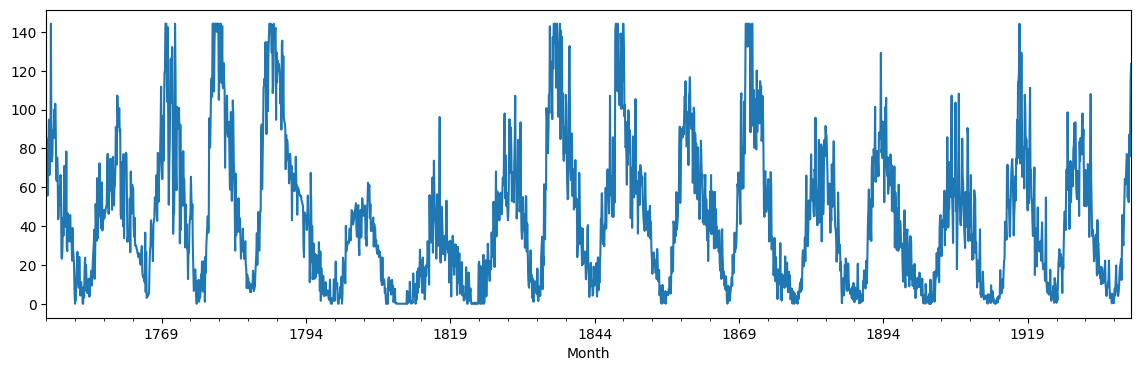

In [123]:
train['value'].plot(figsize=(14, 4))
plt.show()

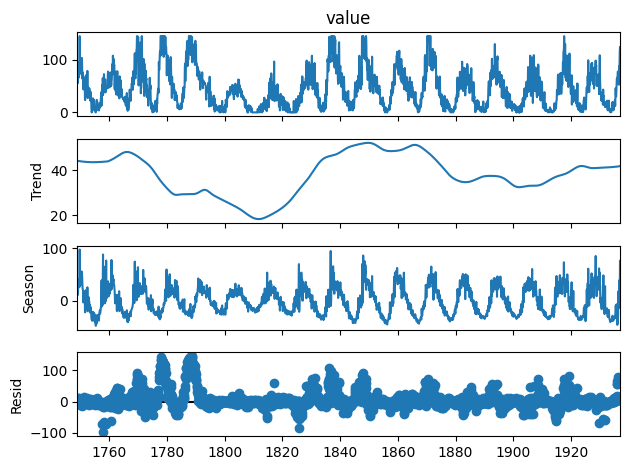

Амплитуда сезонности: ~145.1
Остатки: mean=6.37, std=27.18


In [124]:
stl = STL(train['value'], period=132, robust=True)
result = stl.fit()
result.plot()
plt.tight_layout()
plt.show()

print(f"Амплитуда сезонности: ~{result.seasonal.max() - result.seasonal.min():.1f}")
print(f"Остатки: mean={result.resid.mean():.2f}, std={result.resid.std():.2f}")

In [125]:
series = train['value'].dropna()

adf_orig = adfuller(series)
print(f"Исходный ряд: p-value = {adf_orig[1]:.4f}")
print(f"Стационарен: {'Да' if adf_orig[1] < 0.05 else 'Нет'}")

Исходный ряд: p-value = 0.0000
Стационарен: Да


In [126]:
d = 0

In [127]:
seasonal_period = 132
seasonal_diff = series.diff(seasonal_period).dropna()
adf_seasonal = adfuller(seasonal_diff)

print(f"После сезонного дифференцирования (D=1): p-value = {adf_seasonal[1]:.4f}")
print(f"Стационарен: {'Да' if adf_seasonal[1] < 0.05 else 'Нет'}")

После сезонного дифференцирования (D=1): p-value = 0.0000
Стационарен: Да


In [128]:
D = 1

In [129]:
diff_series = series.diff(seasonal_period).dropna()

print(f"Длина ряда для анализа: {len(diff_series)}")
print(f"Статистика: mean={diff_series.mean():.2f}, std={diff_series.std():.2f}")

Длина ряда для анализа: 2124
Статистика: mean=0.10, std=37.55


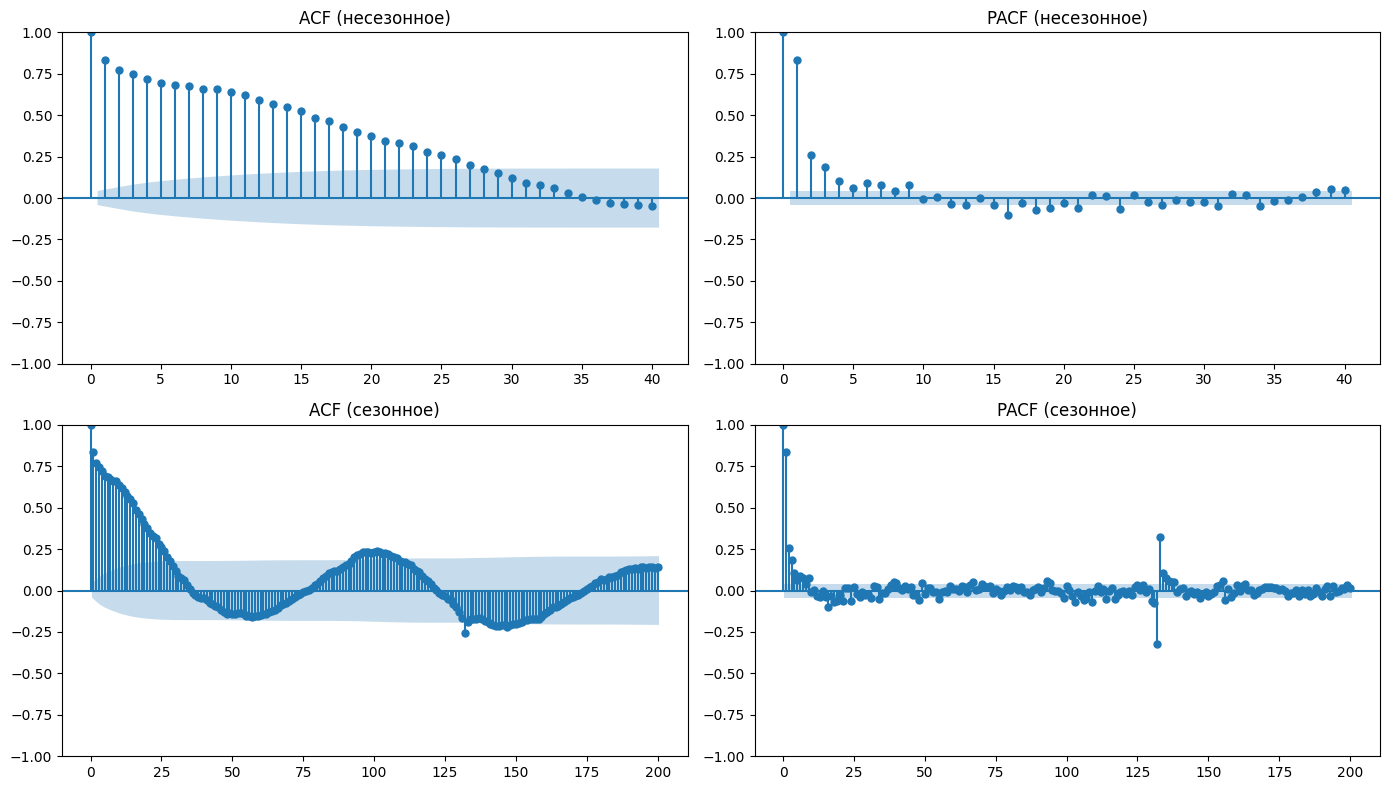

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(diff_series, lags=40, ax=ax[0, 0], title='ACF (несезонное)', alpha=0.05)
plot_pacf(diff_series, lags=40, ax=ax[0, 1], title='PACF (несезонное)', method='ols', alpha=0.05)
plot_acf(diff_series, lags=200, ax=ax[1, 0], title='ACF (сезонное)', alpha=0.05)
plot_pacf(diff_series, lags=200, ax=ax[1, 1], title='PACF (сезонное)', method='ols', alpha=0.05)

plt.tight_layout()
plt.show()

т.к. везде самый значимый лаг - 1, то параметры принимают значения 1.

In [ ]:
# несезонные
p, q = 24, 27
# сезонные
P, Q = 1, 1

In [132]:
print(f"ИТОГОВАЯ МОДЕЛЬ: SARIMA({p},{d},{q})({P},{D},{Q},{seasonal_period})")
print(f"  d={d} — обычное дифференцирование")
print(f"  D={D} — сезонное дифференцирование")  
print(f"  p={p}, q={q} — несезонные AR/MA")
print(f"  P={P}, Q={Q} — сезонные AR/MA")
print(f"  seasonal_period={seasonal_period} — 11-летний цикл")

ИТОГОВАЯ МОДЕЛЬ: SARIMA(1,0,1)(1,1,1,132)
  d=0 — обычное дифференцирование
  D=1 — сезонное дифференцирование
  p=1, q=1 — несезонные AR/MA
  P=1, Q=1 — сезонные AR/MA
  seasonal_period=132 — 11-летний цикл
